In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    mean_squared_error,
    make_scorer
)

In [3]:
store_features = [
    "store_type",
    "store_city",
    "store_state",
    "store_sqft",
    "grocery_sqft",
    "frozen_sqft",
    "meat_sqft",
    "coffee_bar",
    "video_store",
    "salad_bar",
    "prepared_food",
    "florist",
]

product_features = [
    "food_category",
    "food_department",
    "food_family",
    "brand_name",
    "SRP",
    "gross_weight",
    "net_weight",
    "recyclable_package",
    "low_fat",
    "units_per_case",
]

customer_features = [
    "marital_status",
    "gender",
    "total_children",
    "education",
    "member_card",
    "occupation",
    "houseowner",
    "avg_cars_at home(approx)",
    "avg. yearly_income",
    "num_children_at_home",
    # Note: duplcicate row, delete
    # "avg_cars_at home(approx).1",
]

promotion_features = ["promotion_name", "media_type"]

store_and_product_features = [
    "store_sales(in millions)",
    "store_cost(in millions)",
    "unit_sales(in millions)",
]


In [8]:
raw_data = (
    pd.read_csv("E:/NOUR/Documents/PFE/data/media prediction and its cost.csv.zip")
    # we only care about the US -- maybe analyse other countries later
    .query("sales_country == 'USA'").drop(columns="sales_country")
)

In [12]:
store_data = raw_data.loc[:, store_features].drop_duplicates().reset_index(drop=True)


In [13]:
promotion_data = raw_data.loc[:, promotion_features].drop_duplicates().reset_index(drop=True)


In [14]:
product_data = raw_data.loc[:, product_features].drop_duplicates().reset_index(drop=True)


In [15]:
customer_data = raw_data.loc[:, customer_features].drop_duplicates().reset_index(drop=True)

In [16]:
intermedite_data = (
    raw_data
    # duplicate column in dataset
    .drop(columns=["avg_cars_at home(approx).1"])

    # pull out category specifc data and replace it with an ID
    .merge(
        (
            store_data.assign(store_id=lambda df: np.arange(len(df))).set_index(
                store_features
            )
        ),
        on=store_features,
    )
    .drop(columns=store_features)
    .merge(
        (
            customer_data.assign(customer_id=lambda df: np.arange(len(df))).set_index(
                customer_features
            )
        ),
        on=customer_features,
    )
    .drop(columns=customer_features)
    .merge(
        (
            product_data.assign(product_id=lambda df: np.arange(len(df))).set_index(
                product_features
            )
        ),
        on=product_features,
    )
    .drop(columns=product_features)
    .merge(
        (
            promotion_data.assign(promotion_id=lambda df: np.arange(len(df))).set_index(
                promotion_features
            )
        ),
        on=promotion_features,
    )
    .drop(columns=promotion_features)
)

sales_data = intermedite_data.drop(columns=["cost", "customer_id"]).drop_duplicates()

cost_data = intermedite_data.drop(
    columns=[
        "store_sales(in millions)",
        "store_cost(in millions)",
        "unit_sales(in millions)",
    ]
)

NameError: name 'drop_col_level' is not defined

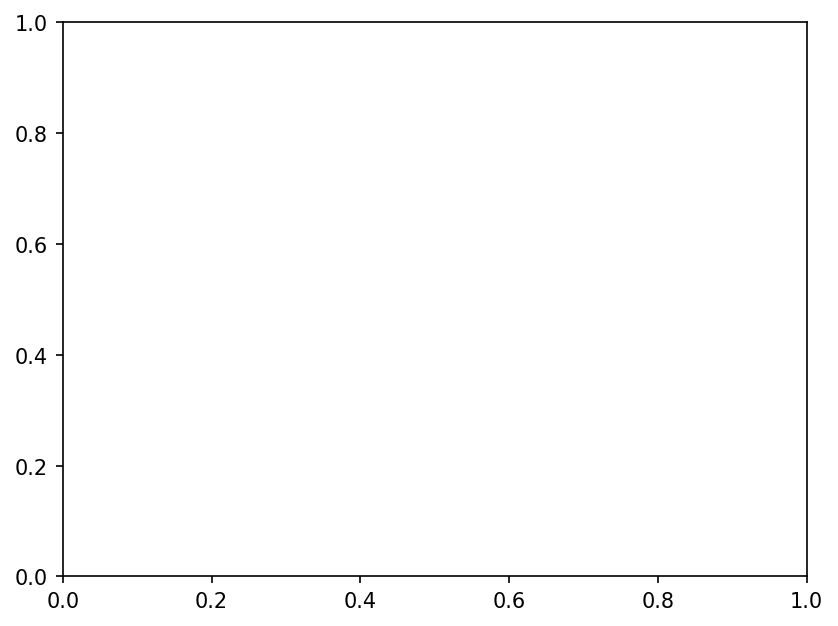

In [11]:
fig, ax = plt.subplots(dpi=150)  # 150 dpi for web presentation (eg slides)
sns.scatterplot(
    (
        cost_data
        .merge(promotion_data, left_on="promotion_id", right_index=True)
        .groupby(["promotion_name"])
        .agg(
            {
                "cost": [("clc", "sum"), ("n_transactions", "count")],
                "store_id": [("n_stores", "nunique")],
            }
        )
        .sort_index()
        .transform(drop_col_level)
    ),
    y="n_transactions",
    x="clc",
    size="n_stores",
    sizes=(50, 300),
    hue="n_stores",
    palette="Blues",
    ax=ax,
)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: str(int(x / 1000)) + "k")
)
ax.set_ylabel("Number of Transactions")
ax.set_xlabel("Total campaign cost (in USD)")
ax.set_title("Campaign cost vs. response rate\n by number of stores involved in each campaign")
ax.legend(title="# Stores")